In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [2]:
from IPython.display import display, Markdown

def quick_overview(df, name, n=5):
    display(Markdown(f"## {name}"))
    display(Markdown(f"**Shape**: {df.shape[0]} rows × {df.shape[1]} columns"))
    
    summary = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_values": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
        "n_unique": df.nunique(dropna=False).values
    })
    
    display(Markdown("### Preview"))
    display(df.head(n).style.set_properties(**{
        "background-color": "#f9f9f9",
        "border-color": "#dddddd",
        "text-align": "left"
    }))
    
    display(Markdown("### Column summary"))
    display(summary.style.background_gradient(cmap="Blues", subset=["missing_values", "missing_pct", "n_unique"]))

In [4]:
production_df = pd.read_parquet("../data/dataset_1.parquet")
coords_df = pd.read_parquet("../data/dataset_2.parquet")
weather_df = pd.read_parquet("../data/dataset_3.parquet")

In [5]:
quick_overview(production_df, "Production dataset")
quick_overview(coords_df, "Coordinates dataset")
quick_overview(weather_df, "Weather dataset")

## Production dataset

**Shape**: 274800 rows × 4 columns

### Preview

,site_name,delivery_time,production,installed_capacity
0,Nobelwind Offshore Windpark,2022-12-31 23:00:00+00:00,162.717500,165.000000
1,Nobelwind Offshore Windpark,2023-01-01 00:00:00+00:00,162.685000,165.000000
2,Nobelwind Offshore Windpark,2023-01-01 01:00:00+00:00,162.680000,165.000000
3,Nobelwind Offshore Windpark,2023-01-01 02:00:00+00:00,162.730000,165.000000
4,Nobelwind Offshore Windpark,2023-01-01 03:00:00+00:00,162.712500,165.000000


### Column summary

...

**Shape**: 275280 rows × 23 columns

### Preview

,site_name,delivery_time,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,temperature_2m,dewpoint_2m,apparent_temperature,pressure_msl,surface_pressure,precipitation,snowfall,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,shortwave_radiation,direct_radiation,diffuse_radiation,weather_code,sunshine_duration
0,Belwind Phase 1,2023-01-01 00:00:00+00:00,14.603082,19.897738,218.047090,219.289400,20.700000,12.250000,8.850000,4.282408,1005.600000,1005.600000,0.200000,0.000000,100.000000,53.000000,100.000000,98.000000,0.000000,0.000000,0.000000,51.000000,0.000000
1,Belwind Phase 1,2023-01-01 01:00:00+00:00,16.182089,21.681328,215.949370,217.504210,20.800000,12.100000,8.800000,3.290131,1005.400000,1005.400000,0.100000,0.000000,100.000000,18.000000,100.000000,100.000000,0.000000,0.000000,0.000000,51.000000,0.000000
2,Belwind Phase 1,2023-01-01 02:00:00+00:00,17.969420,23.809662,226.803970,228.746260,24.100000,11.850000,9.500000,2.291797,1006.400000,1006.400000,0.200000,0.000000,100.000000,31.000000,100.000000,100.000000,0.000000,0.000000,0.000000,51.000000,0.000000
3,Belwind Phase 1,2023-01-01 03:00:00+00:00,14.792228,19.860010,227.465790,229.492660,23.900000,11.800000,9.850000,4.007824,1007.200000,1007.200000,0.000000,0.000000,100.000000,27.000000,24.000000,100.000000,0.000000,0.000000,0.000000,3.000000,0.000000
4,Belwind Phase 1,2023-01-01 04:00:00+00:00,15.001333,19.915070,227.161090,228.868300,19.700000,11.750000,9.300000,3.694952,1007.900000,1007.900000,0.000000,0.000000,100.000000,3.000000,45.000000,100.000000,0.000000,0.000000,0.000000,3.000000,0.000000


### Column summary

,column,dtype,missing_values,missing_pct,n_unique
0,site_name,str,0,0.000000,10
1,delivery_time,str,0,0.000000,27528
2,wind_speed_10m,float64,0,0.000000,22493
3,wind_speed_100m,float64,0,0.000000,30071
4,wind_direction_10m,float64,0,0.000000,47318
5,wind_direction_100m,float64,0,0.000000,56370
6,wind_gusts_10m,float64,0,0.000000,307
7,temperature_2m,float64,0,0.000000,522
8,dewpoint_2m,float64,0,0.000000,525
9,apparent_temperature,float64,0,0.000000,137093


In [6]:
datasets_summary = pd.DataFrame({
    "dataset": ["production", "coordinates", "weather"],
    "rows": [len(production_df), len(coords_df), len(weather_df)],
    "columns": [production_df.shape[1], coords_df.shape[1], weather_df.shape[1]],
    "missing_cells": [
        production_df.isna().sum().sum(),
        coords_df.isna().sum().sum(),
        weather_df.isna().sum().sum()
    ]
})

datasets_summary.style.hide(axis="index").background_gradient(cmap="Greens")

dataset,rows,columns,missing_cells
production,274800,4,96
coordinates,10,3,0
weather,275280,23,0


In [7]:
def missing_table(df):
    out = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2)
    }).sort_values("missing_count", ascending=False)
    return out[out["missing_count"] > 0]

display(missing_table(production_df).style.background_gradient(cmap="Oranges"))
display(missing_table(coords_df).style.background_gradient(cmap="Oranges"))
display(missing_table(weather_df).style.background_gradient(cmap="Oranges"))

,missing_count,missing_pct
production,96,0.030000


,missing_count,missing_pct


,missing_count,missing_pct


In [8]:
print("Production duplicates:", production_df.duplicated().sum())
print("Coordinates duplicates:", coords_df.duplicated().sum())
print("Weather duplicates:", weather_df.duplicated().sum())

Production duplicates: 0
Coordinates duplicates: 0
Weather duplicates: 0


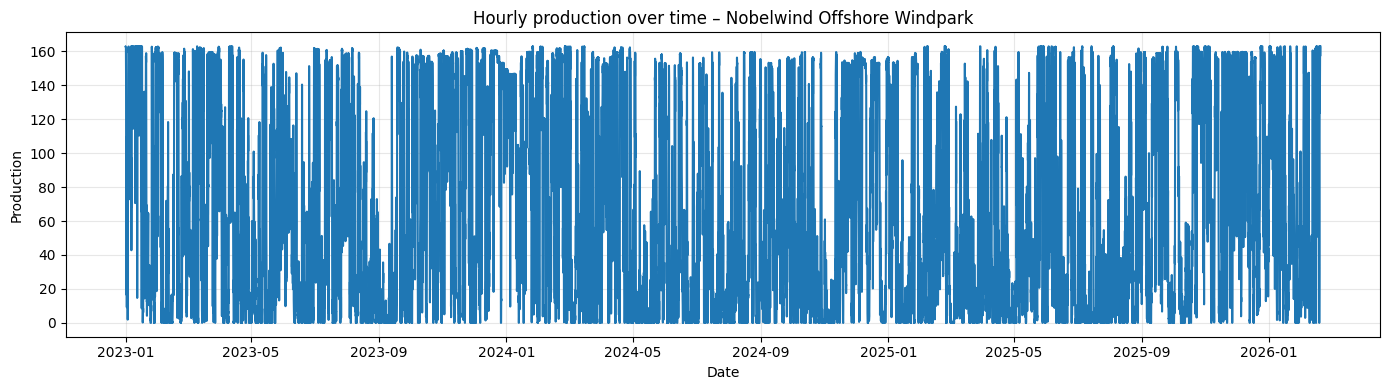

In [10]:
production_df["delivery_time"] = pd.to_datetime(production_df["delivery_time"])

site_example = production_df["site_name"].iloc[0]
tmp = production_df[production_df["site_name"] == site_example].sort_values("delivery_time")

plt.figure(figsize=(14, 4))
plt.plot(tmp["delivery_time"], tmp["production"])
plt.title(f"Hourly production over time – {site_example}")
plt.xlabel("Date")
plt.ylabel("Production")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

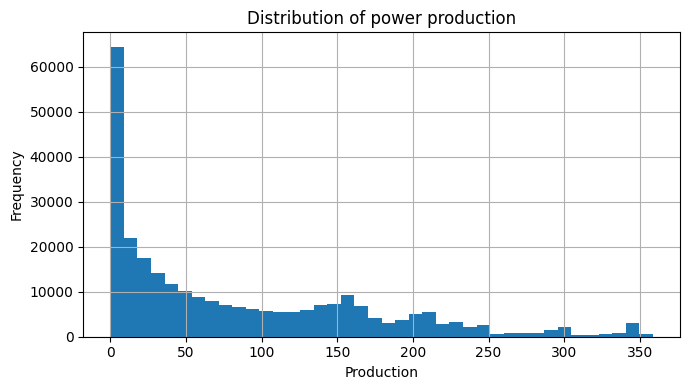

In [11]:
plt.figure(figsize=(7, 4))
production_df["production"].hist(bins=40)
plt.title("Distribution of power production")
plt.xlabel("Production")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

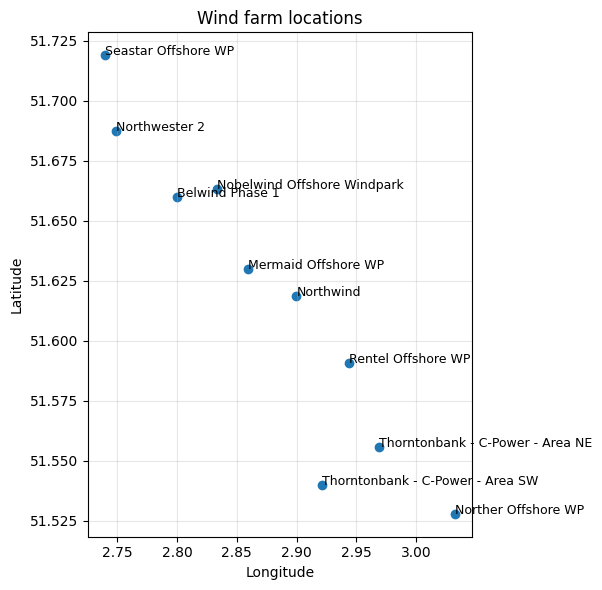

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(coords_df["longitude"], coords_df["latitude"])

for _, row in coords_df.iterrows():
    plt.text(row["longitude"], row["latitude"], str(row["site_name"]), fontsize=9)

plt.title("Wind farm locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
weather_cols = pd.DataFrame({
    "weather_feature": weather_df.columns
})

display(weather_cols.style.hide(axis="index"))

weather_feature
site_name
delivery_time
wind_speed_10m
wind_speed_100m
wind_direction_10m
wind_direction_100m
wind_gusts_10m
temperature_2m
dewpoint_2m
apparent_temperature


In [14]:
def dataset_card(df, name):
    return {
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing (%)": round(df.isna().mean().mean() * 100, 2),
        "Duplicates": int(df.duplicated().sum())
    }

cards = pd.DataFrame([
    dataset_card(production_df, "Production"),
    dataset_card(coords_df, "Coordinates"),
    dataset_card(weather_df, "Weather")
])

display(cards.style.hide(axis="index").background_gradient(cmap="PuBu"))

Dataset,Rows,Columns,Missing (%),Duplicates
Production,274800,4,0.010000,0
Coordinates,10,3,0.000000,0
Weather,275280,23,0.000000,0
